# MoveData — PBL Fase 5
## Desafio: Monitor Inteligente de Transporte Público (ônibus autônomos - Cidade Alfa)
Grupo: Gabriel Soares, Isadora Maciel, João Boone, Juliana Larissa Napoli, Quéren Matos

## 1. Preparação e qualidade dos dados

In [1]:

import pandas as pd
# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregando as bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

df_eventos = pd.read_excel(
    caminho,
    sheet_name="eventos_parada_cidade_alfa"
)

print("Base de viagens:")
print(df_viagens.head())

print("\nBase de eventos de parada:")
print(df_eventos.head())

# Inspeção inicial das bases

print("Dimensões da base de viagens:")
print(df_viagens.shape)

print("\nDimensões da base de eventos:")
print(df_eventos.shape)

print("\n=== TIPOS DE DADOS - BASE DE VIAGENS ===")
print(df_viagens.dtypes.to_string())

print("\n=== TIPOS DE DADOS - BASE DE EVENTOS ===")
print(df_eventos.dtypes.to_string())

# Verificação de valores nulos

print("\n=== VALORES NULOS - BASE DE VIAGENS ===")
print(df_viagens.isnull().sum())

print("\n=== VALORES NULOS - BASE DE EVENTOS ===")
print(df_eventos.isnull().sum())

""" 
Resultado:
Não foram identificados valores nulos em nenhuma das duas bases.
Portanto, não foi necessário realizar imputação ou remoção de registros
por ausência de dados.
"""

# Verificação de registros duplicados

print("\n=== DUPLICIDADES - BASE DE VIAGENS ===")
print("Registros duplicados:", df_viagens.duplicated().sum())

print("\n=== DUPLICIDADES - BASE DE EVENTOS ===")
print("Registros duplicados:", df_eventos.duplicated().sum())

# Carregando o dicionário de dados

df_dicionario = pd.read_excel(
    caminho,
    sheet_name="dicionario_dados"
)

print("\n=== DICIONÁRIO DE DADOS ===")
print(df_dicionario.to_string(index=False))

# Verificação de valores negativos

colunas_nao_negativas_viagens = [
    "distancia_km",
    "tempo_previsto_min",
    "tempo_real_min",
    "velocidade_media_kmh",
    "congestionamento_pct",
    "qt_paradas",
    "qt_passageiros_embarcados",
    "ocupacao_media_pct",
    "ocupacao_maxima_pct",
    "tempo_medio_parada_min",
    "paradas_com_atraso",
    "chuva_mm",
    "qt_incidentes",
    "consumo_energia_kwh",
    "eficiencia_kwh_km"
]

print("\n=== VALORES NEGATIVOS - BASE DE VIAGENS ===")

for coluna in colunas_nao_negativas_viagens:
    quantidade = (df_viagens[coluna] < 0).sum()
    print(f"{coluna}: {quantidade}")

# Verificação dos percentuais - Base de viagens

colunas_percentuais_viagens = [
    "congestionamento_pct",
    "ocupacao_media_pct",
    "ocupacao_maxima_pct"
]

print("\n=== VALORES FORA DA FAIXA 0-100% - BASE DE VIAGENS ===")

for coluna in colunas_percentuais_viagens:
    fora_faixa = ((df_viagens[coluna] < 0) | (df_viagens[coluna] > 100)).sum()
    print(f"{coluna}: {fora_faixa}")

# Verificação dos percentuais - Base de eventos

print("\n=== VALORES FORA DA FAIXA 0-100% - BASE DE EVENTOS ===")

fora_faixa = (
    (df_eventos["ocupacao_pct"] < 0) |
    (df_eventos["ocupacao_pct"] > 100)
).sum()

print(f"ocupacao_pct: {fora_faixa}")

# Verificação de integridade referencial

viagens_ids = set(df_viagens["id_viagem"])

eventos_sem_viagem = ~df_eventos["id_viagem"].isin(viagens_ids)

print("\n=== INTEGRIDADE REFERENCIAL ===")
print(
    "Eventos com id_viagem inexistente na base de viagens:",
    eventos_sem_viagem.sum()
)

# Verificação da consistência do atraso

atraso_calculado = (
    df_viagens["tempo_real_min"] -
    df_viagens["tempo_previsto_min"]
)

inconsistencias_atraso = (
    atraso_calculado != df_viagens["atraso_min"]
).sum()

print("\n=== CONSISTÊNCIA DO ATRASO ===")
print(
    "Registros em que atraso_min não corresponde "
    "à diferença entre tempo real e previsto:",
    inconsistencias_atraso
)

# Verificação da consistência da ocupação

inconsistencias_ocupacao = (
    df_viagens["ocupacao_maxima_pct"] <
    df_viagens["ocupacao_media_pct"]
).sum()

print("\n=== CONSISTÊNCIA DA OCUPAÇÃO ===")
print(
    "Viagens em que a ocupação máxima é menor que a ocupação média:",
    inconsistencias_ocupacao
)

# Verificação da consistência das paradas com atraso

inconsistencias_paradas = (
    df_viagens["paradas_com_atraso"] >
    df_viagens["qt_paradas"]
).sum()

print("\n=== CONSISTÊNCIA DAS PARADAS ===")
print(
    "Viagens em que o número de paradas com atraso "
    "é maior que o total de paradas:",
    inconsistencias_paradas
)

# Verificação das datas

print("\n=== PERÍODO DA BASE DE VIAGENS ===")
print("Data inicial:", df_viagens["data_viagem"].min())
print("Data final:", df_viagens["data_viagem"].max())

print("\n=== PERÍODO DA BASE DE EVENTOS ===")
print("Data inicial:", df_eventos["data_evento"].min())
print("Data final:", df_eventos["data_evento"].max())

# Categorias existentes

print("\n=== CATEGORIAS - DIA DA SEMANA ===")
print(df_viagens["dia_semana"].value_counts())

print("\n=== CATEGORIAS - PERÍODO ===")
print(df_viagens["periodo"].value_counts())

print("\n=== CATEGORIAS - TIPO DE INCIDENTE ===")
print(df_viagens["tipo_incidente"].value_counts())

print("\n=== CATEGORIAS - STATUS DA VIAGEM ===")
print(df_viagens["status_viagem"].value_counts())

# Quantidade de eventos por viagem

eventos_por_viagem = df_eventos.groupby("id_viagem").size()

print("\n=== EVENTOS POR VIAGEM ===")
print(eventos_por_viagem.describe())

# Consistência entre quantidade de paradas e eventos registrados

eventos_por_viagem = df_eventos.groupby("id_viagem").size()

comparacao_paradas = df_viagens[["id_viagem", "qt_paradas"]].copy()

comparacao_paradas["eventos_registrados"] = (
    comparacao_paradas["id_viagem"].map(eventos_por_viagem)
)

comparacao_paradas["diferenca"] = (
    comparacao_paradas["qt_paradas"]
    - comparacao_paradas["eventos_registrados"]
)

inconsistencias = comparacao_paradas[
    comparacao_paradas["diferenca"] != 0
]

print("\n=== CONSISTÊNCIA ENTRE PARADAS E EVENTOS ===")
print(
    "Viagens com diferença entre qt_paradas e eventos:",
    len(inconsistencias)
)

if len(inconsistencias) > 0:
    print("\nExemplos de inconsistências:")
    print(inconsistencias.head())

""" 
CONCLUSÃO DA QUALIDADE DOS DADOS

As bases de viagens e eventos foram avaliadas quanto a:
- valores nulos
- registros duplicados
- valores negativos
- limites de variáveis percentuais
- integridade referencial
- consistência entre variáveis
- consistência entre as bases

Não foram identificadas inconsistências que exigissem
exclusão ou correção de registros.

As bases estão aptas para a etapa de análise estatística.
"""

Base de viagens:
   id_viagem  id_onibus  id_linha data_viagem hora_inicio dia_semana  \
0          1          8        36  2026-03-19    16:38:00     Quinta   
1          2         62         3  2026-07-24    19:42:00      Sexta   
2          3         53        16  2026-01-09    16:16:00      Sexta   
3          4         36        19  2026-04-19    15:21:00    Domingo   
4          5         35        32  2026-07-14    13:56:00      Terca   

      periodo  distancia_km  tempo_previsto_min  tempo_real_min  ...  \
0   Entrepico          11.7                  22              21  ...   
1  Pico_Tarde          23.2                  41              51  ...   
2   Entrepico          25.9                  52              54  ...   
3   Entrepico          10.3                  21              30  ...   
4   Entrepico           7.1                  13              17  ...   

   tempo_medio_parada_min  paradas_com_atraso  temperatura_c  chuva_mm  \
0                    1.21                  

' \nCONCLUSÃO DA QUALIDADE DOS DADOS\n\nAs bases de viagens e eventos foram avaliadas quanto a:\n- valores nulos\n- registros duplicados\n- valores negativos\n- limites de variáveis percentuais\n- integridade referencial\n- consistência entre variáveis\n- consistência entre as bases\n\nNão foram identificadas inconsistências que exigissem\nexclusão ou correção de registros.\n\nAs bases estão aptas para a etapa de análise estatística.\n'

## 2. Análise estatística e investigação dos dados

### Hipótese 1 — Congestionamento x Atraso

Bases carregadas com sucesso!
Viagens: (2000, 28)
Eventos: (27413, 12)

=== H1 - CONGESTIONAMENTO X ATRASO ===

Estatísticas do congestionamento:
count    2000.000000
mean       43.420000
std        22.981333
min         0.000000
25%        27.000000
50%        42.000000
75%        61.000000
max        95.000000
Name: congestionamento_pct, dtype: float64

Estatísticas do atraso:
count    2000.000000
mean        3.466500
std         4.947334
min        -8.000000
25%         0.000000
50%         3.000000
75%         7.000000
max        22.000000
Name: atraso_min, dtype: float64


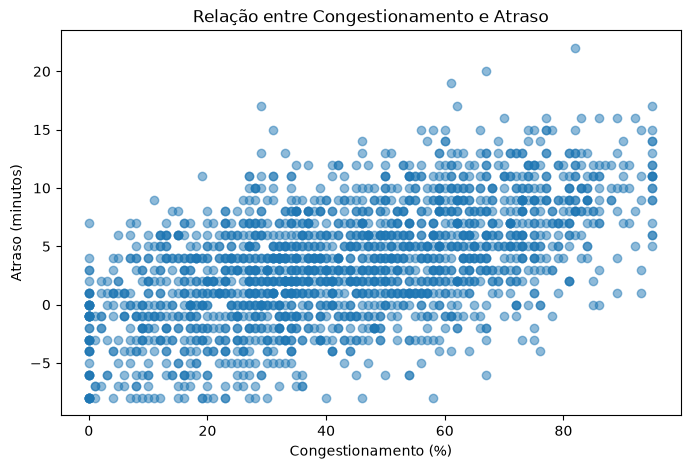


=== CORRELAÇÃO (Pearson)- H1 ===
Correlação: 0.5633

=== TESTE DE NORMALIDADE - H1 ===
Congestionamento: p-valor = 0.000000
Atraso: p-valor = 0.000000
Congestionamento: distribuição não normal.
Atraso: distribuição não normal.

=== TESTE DE SPEARMAN - H1 ===
Correlação de Spearman: 0.5506
P-valor: 0.000000
Resultado: rejeitamos H0.
Existe associação estatisticamente significativa entre congestionamento e atraso.


In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, spearmanr
import matplotlib.pyplot as plt

# Pasta de saida dos graficos (PNG para o relatorio)
PASTA_GRAFICOS = os.path.join("relatorio", "graficos")
os.makedirs(PASTA_GRAFICOS, exist_ok=True)


# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregando as bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

df_eventos = pd.read_excel(
    caminho,
    sheet_name="eventos_parada_cidade_alfa"
)

print("Bases carregadas com sucesso!")
print(f"Viagens: {df_viagens.shape}")
print(f"Eventos: {df_eventos.shape}")

# H1 - Congestionamento x Atraso

print("\n=== H1 - CONGESTIONAMENTO X ATRASO ===")

print("\nEstatísticas do congestionamento:")
print(df_viagens["congestionamento_pct"].describe())

print("\nEstatísticas do atraso:")
print(df_viagens["atraso_min"].describe())

# Relação entre congestionamento e atraso


plt.figure(figsize=(8, 5))

plt.scatter(
    df_viagens["congestionamento_pct"],
    df_viagens["atraso_min"],
    alpha=0.5
)

plt.xlabel("Congestionamento (%)")
plt.ylabel("Atraso (minutos)")
plt.title("Relação entre Congestionamento e Atraso")

plt.savefig(
    os.path.join(PASTA_GRAFICOS, "H1_congestionamento_atraso.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# Correlação - H1
correlacao = df_viagens["congestionamento_pct"].corr(
    df_viagens["atraso_min"]
)

print("\n=== CORRELAÇÃO (Pearson)- H1 ===")
print(f"Correlação: {correlacao:.4f}")

# H1 - Congestionamento x Atraso
# Hipótese: quanto maior o congestionamento, maior tende a ser o atraso.
# Variáveis analisadas: congestionamento_pct e atraso_min

# Teste de normalidade - Shapiro-Wilk

print("\n=== TESTE DE NORMALIDADE - H1 ===")

stat_cong, p_cong = shapiro(df_viagens["congestionamento_pct"])
stat_atraso, p_atraso = shapiro(df_viagens["atraso_min"])

print(f"Congestionamento: p-valor = {p_cong:.6f}")
print(f"Atraso: p-valor = {p_atraso:.6f}")

alpha = 0.05

if p_cong < alpha:
    print("Congestionamento: distribuição não normal.")
else:
    print("Congestionamento: não há evidências suficientes para rejeitar a normalidade.")

if p_atraso < alpha:
    print("Atraso: distribuição não normal.")
else:
    print("Atraso: não há evidências suficientes para rejeitar a normalidade.")

# Correlação de Spearman

print("\n=== TESTE DE SPEARMAN - H1 ===")

rho, p_valor = spearmanr(
    df_viagens["congestionamento_pct"],
    df_viagens["atraso_min"]
)

print(f"Correlação de Spearman: {rho:.4f}")
print(f"P-valor: {p_valor:.6f}")

alpha = 0.05

if p_valor < alpha:
    print("Resultado: rejeitamos H0.")
    print("Existe associação estatisticamente significativa entre congestionamento e atraso.")
else:
    print("Resultado: não rejeitamos H0.")
    print("Não há evidências estatísticas suficientes de associação entre congestionamento e atraso.")

### Hipótese 2 — Período do dia x Atraso médio (corrigida)
**Correção aplicada:** a hipótese original comparava *médias* de atraso entre períodos, mas o teste anterior usava qui-quadrado sobre uma variável binária (atrasado/no horário), o que responde a uma pergunta diferente. Como estamos comparando uma variável numérica (atraso) entre mais de dois grupos (períodos), o teste correto é Kruskal-Wallis (a distribuição do atraso não é normal em todos os períodos, confirmado pelo teste de Shapiro-Wilk).

Bases carregadas com sucesso!
Viagens: (2000, 28)

=== H2 - PERÍODO DO DIA X ATRASO MÉDIO ===

Estatísticas descritivas do atraso por período:
                mean  median       std  count
periodo                                      
Entrepico   2.353165     2.0  4.611451    790
Noturno     1.024096     1.0  4.333824    415
Pico_Manha  5.811441     6.0  4.561963    472
Pico_Tarde  5.900929     6.0  4.529691    323

=== TESTE DE NORMALIDADE POR PERÍODO (Shapiro-Wilk) ===
Entrepico: p-valor = 0.000235
Pico_Tarde: p-valor = 0.057456
Pico_Manha: p-valor = 0.053039
Noturno: p-valor = 0.001328

Pelo menos um período não segue distribuição normal.
Optamos pelo teste não paramétrico de Kruskal-Wallis.


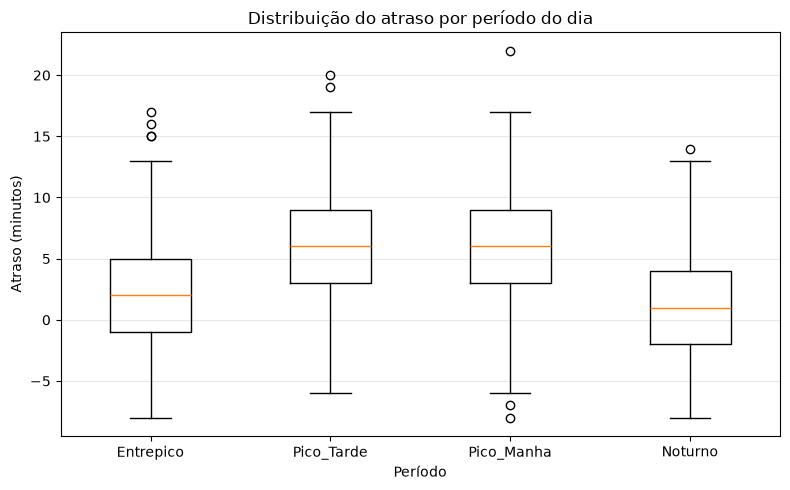


=== TESTE DE KRUSKAL-WALLIS - H2 ===
Estatística H: 319.5291
P-valor: < 0.001

Resultado: rejeitamos H0.
Há diferença estatisticamente significativa no atraso médio entre pelo menos dois períodos do dia.

=== TESTE POST-HOC DE DUNN (Bonferroni) - H2 ===

Matriz de p-valores ajustados:
            Entrepico   Noturno  Pico_Manha  Pico_Tarde
Entrepico    1.000000  0.000036         0.0         0.0
Noturno      0.000036  1.000000         0.0         0.0
Pico_Manha   0.000000  0.000000         1.0         1.0
Pico_Tarde   0.000000  0.000000         1.0         1.0

Comparações par a par:
Entrepico x Noturno: p = 0.000036 (diferença significativa)
Entrepico x Pico_Manha: p = 0.000000 (diferença significativa)
Entrepico x Pico_Tarde: p = 0.000000 (diferença significativa)
Noturno x Pico_Manha: p = 0.000000 (diferença significativa)
Noturno x Pico_Tarde: p = 0.000000 (diferença significativa)
Pico_Manha x Pico_Tarde: p = 1.000000 (sem diferença significativa)

--- Conclusão do post-hoc ---
Do

'\nCONCLUSÃO - H2\n\nO teste de Kruskal-Wallis mostrou diferença estatisticamente significativa\nno atraso entre os períodos do dia (p < 0.001).\n\nObservando as médias por período, os horários de Pico da Manhã e\nPico da Tarde apresentam atraso médio consideravelmente maior\n(em torno de 5,8 a 5,9 minutos) do que os períodos de Entrepico\n(2,4 minutos) e Noturno (1,0 minuto).\n\nO teste post-hoc de Dunn com correção de Bonferroni confirma essa\nleitura: 5 dos 6 pares de períodos apresentam diferença significativa.\nA única exceção é Pico da Manhã x Pico da Tarde (p = 1,000), ou seja,\nos dois horários de pico têm atraso equivalente entre si, mas ambos\ndiferem de Entrepico e de Noturno.\n\nIsso confirma a hipótese de que viagens em horário de pico\napresentam maior atraso médio, reforçando a recomendação de reforço\noperacional nos horários de pico já presente no dashboard.\n'

In [3]:
import os
import pandas as pd
import numpy as np
from scipy.stats import shapiro, kruskal
from scikit_posthocs import posthoc_dunn
import matplotlib.pyplot as plt

# Pasta de saida dos graficos (PNG para o relatorio)
PASTA_GRAFICOS = os.path.join("relatorio", "graficos")
os.makedirs(PASTA_GRAFICOS, exist_ok=True)


# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregando as bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

print("Bases carregadas com sucesso!")
print(f"Viagens: {df_viagens.shape}")

# ============================================================
# H2 - PERÍODO DO DIA X ATRASO MÉDIO
# ============================================================
# Hipótese: viagens em horário de pico apresentam maior atraso médio
# H0 = Não há diferença significativa no atraso médio entre os períodos
# H1 = Há diferença significativa no atraso médio entre pelo menos dois períodos
# Variáveis: periodo (categórica) x atraso_min (numérica)
#
# Como estamos comparando a MÉDIA de uma variável numérica (atraso_min)
# entre MAIS DE DOIS grupos (períodos), o teste adequado é uma ANOVA
# (paramétrico) ou o Kruskal-Wallis (não paramétrico, equivalente à ANOVA
# quando os dados não seguem distribuição normal).

print("\n=== H2 - PERÍODO DO DIA X ATRASO MÉDIO ===")

print("\nEstatísticas descritivas do atraso por período:")
print(df_viagens.groupby("periodo")["atraso_min"].agg(["mean", "median", "std", "count"]))

# ============================================================
# TESTE DE NORMALIDADE POR GRUPO (Shapiro-Wilk)
# ============================================================
# Verificamos a normalidade do atraso dentro de cada período para decidir
# entre ANOVA (dados normais) e Kruskal-Wallis (dados não normais).

print("\n=== TESTE DE NORMALIDADE POR PERÍODO (Shapiro-Wilk) ===")

alpha = 0.05
algum_grupo_nao_normal = False

for periodo in df_viagens["periodo"].unique():
    amostra = df_viagens[df_viagens["periodo"] == periodo]["atraso_min"]
    stat, p_valor = shapiro(amostra)
    print(f"{periodo}: p-valor = {p_valor:.6f}")
    if p_valor < alpha:
        algum_grupo_nao_normal = True

if algum_grupo_nao_normal:
    print("\nPelo menos um período não segue distribuição normal.")
    print("Optamos pelo teste não paramétrico de Kruskal-Wallis.")
else:
    print("\nTodos os períodos são compatíveis com distribuição normal.")
    print("A ANOVA também seria adequada, mas seguimos com Kruskal-Wallis "
          "por ser mais robusto.")

# ============================================================
# BOXPLOT - ATRASO POR PERÍODO
# ============================================================

grupos_labels = df_viagens["periodo"].unique()
dados_boxplot = [
    df_viagens[df_viagens["periodo"] == p]["atraso_min"]
    for p in grupos_labels
]

plt.figure(figsize=(8, 5))
plt.boxplot(dados_boxplot, tick_labels=grupos_labels)
plt.title("Distribuição do atraso por período do dia")
plt.xlabel("Período")
plt.ylabel("Atraso (minutos)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(PASTA_GRAFICOS, "H2_periodo_atraso.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# TESTE DE KRUSKAL-WALLIS - H2
# ============================================================

print("\n=== TESTE DE KRUSKAL-WALLIS - H2 ===")

grupos = [
    df_viagens[df_viagens["periodo"] == p]["atraso_min"]
    for p in df_viagens["periodo"].unique()
]

estatistica_h, p_valor = kruskal(*grupos)

print(f"Estatística H: {estatistica_h:.4f}")

if p_valor < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_valor:.6f}")

if p_valor < alpha:
    print("\nResultado: rejeitamos H0.")
    print(
        "Há diferença estatisticamente significativa no atraso médio "
        "entre pelo menos dois períodos do dia."
    )
else:
    print("\nResultado: não rejeitamos H0.")
    print(
        "Não há evidências estatísticas suficientes de diferença "
        "no atraso médio entre os períodos."
    )

# ============================================================
# TESTE POST-HOC DE DUNN (Bonferroni) - H2
# ============================================================
# O Kruskal-Wallis é um teste omnibus: indica que pelo menos dois períodos
# diferem, mas não diz quais. O post-hoc de Dunn compara todos os pares,
# e a correção de Bonferroni ajusta os p-valores pelo número de comparações
# (6 pares), evitando falsos positivos por testagem múltipla.

print("\n=== TESTE POST-HOC DE DUNN (Bonferroni) - H2 ===")

matriz_dunn = posthoc_dunn(
    df_viagens,
    val_col="atraso_min",
    group_col="periodo",
    p_adjust="bonferroni"
)

print("\nMatriz de p-valores ajustados:")
print(matriz_dunn.round(6).to_string())

# Leitura par a par (a partir do próprio resultado do teste)

print("\nComparações par a par:")

periodos_ordenados = list(matriz_dunn.columns)
pares_diferentes = []
pares_iguais = []

for i, periodo_a in enumerate(periodos_ordenados):
    for periodo_b in periodos_ordenados[i + 1:]:
        p_par = matriz_dunn.loc[periodo_a, periodo_b]

        if p_par < alpha:
            resultado = "diferença significativa"
            pares_diferentes.append((periodo_a, periodo_b))
        else:
            resultado = "sem diferença significativa"
            pares_iguais.append((periodo_a, periodo_b))

        print(f"{periodo_a} x {periodo_b}: p = {p_par:.6f} ({resultado})")

# Conclusão do post-hoc

print("\n--- Conclusão do post-hoc ---")

verbo_diferentes = "apresenta" if len(pares_diferentes) == 1 else "apresentam"
verbo_iguais = "apresenta" if len(pares_iguais) == 1 else "apresentam"

print(
    f"Dos {len(pares_diferentes) + len(pares_iguais)} pares comparados, "
    f"{len(pares_diferentes)} {verbo_diferentes} diferença estatisticamente "
    f"significativa no atraso e {len(pares_iguais)} não {verbo_iguais}."
)

if pares_diferentes:
    print("\nPares com diferença significativa (p < 0.05):")
    for periodo_a, periodo_b in pares_diferentes:
        print(f"  - {periodo_a} x {periodo_b}")

if pares_iguais:
    print("\nPares sem diferença significativa (p >= 0.05):")
    for periodo_a, periodo_b in pares_iguais:
        print(f"  - {periodo_a} x {periodo_b}")

# ============================================================
# CONCLUSÃO - H2
# ============================================================

"""
CONCLUSÃO - H2

O teste de Kruskal-Wallis mostrou diferença estatisticamente significativa
no atraso entre os períodos do dia (p < 0.001).

Observando as médias por período, os horários de Pico da Manhã e
Pico da Tarde apresentam atraso médio consideravelmente maior
(em torno de 5,8 a 5,9 minutos) do que os períodos de Entrepico
(2,4 minutos) e Noturno (1,0 minuto).

O teste post-hoc de Dunn com correção de Bonferroni confirma essa
leitura: 5 dos 6 pares de períodos apresentam diferença significativa.
A única exceção é Pico da Manhã x Pico da Tarde (p = 1,000), ou seja,
os dois horários de pico têm atraso equivalente entre si, mas ambos
diferem de Entrepico e de Noturno.

Isso confirma a hipótese de que viagens em horário de pico
apresentam maior atraso médio, reforçando a recomendação de reforço
operacional nos horários de pico já presente no dashboard.
"""


### Hipótese 3 — Chuva x Congestionamento

Bases carregadas com sucesso!
Viagens: (2000, 28)
Eventos: (27413, 12)

=== H3 - CHUVA X CONGESTIONAMENTO ===

Estatísticas da chuva:
count    2000.000000
mean        2.012550
std         4.192405
min         0.000000
25%         0.000000
50%         0.000000
75%         2.125000
max        34.300000
Name: chuva_mm, dtype: float64

Estatísticas do congestionamento:
count    2000.000000
mean       43.420000
std        22.981333
min         0.000000
25%        27.000000
50%        42.000000
75%        61.000000
max        95.000000
Name: congestionamento_pct, dtype: float64


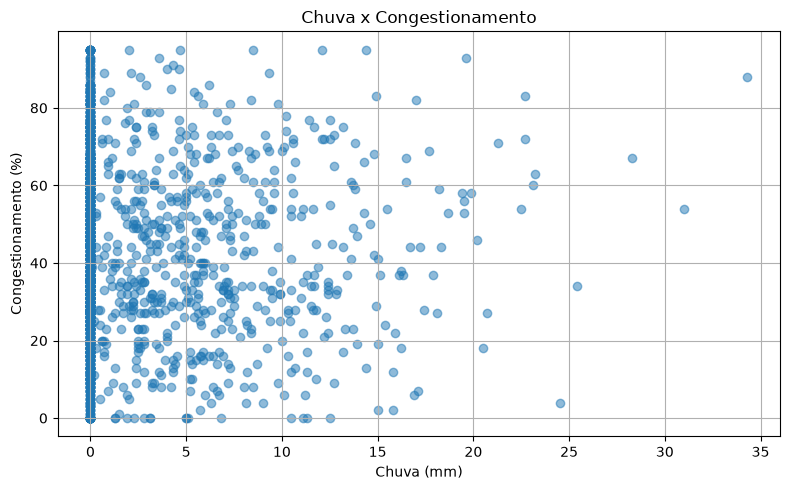


=== CORRELAÇÃO DE PEARSON - H3 ===
Correlação de Pearson: -0.0059
P-valor: 0.7905

=== CORRELAÇÃO DE SPEARMAN - H3 ===
Correlação de Spearman: -0.0382
P-valor: 0.0874

=== CONCLUSÃO - H3 ===
Resultado: não rejeitamos H0.
Não há evidências estatísticas suficientes para afirmar que maiores volumes de chuva estejam associados a maiores níveis de congestionamento.


In [4]:
import os
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, chi2_contingency, pearsonr
import matplotlib.pyplot as plt

# Pasta de saida dos graficos (PNG para o relatorio)
PASTA_GRAFICOS = os.path.join("relatorio", "graficos")
os.makedirs(PASTA_GRAFICOS, exist_ok=True)


# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregando as bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

df_eventos = pd.read_excel(
    caminho,
    sheet_name="eventos_parada_cidade_alfa"
)

print("Bases carregadas com sucesso!")
print(f"Viagens: {df_viagens.shape}")
print(f"Eventos: {df_eventos.shape}")

print("\n=== H3 - CHUVA X CONGESTIONAMENTO ===")

print("\nEstatísticas da chuva:")
print(df_viagens["chuva_mm"].describe())

print("\nEstatísticas do congestionamento:")
print(df_viagens["congestionamento_pct"].describe())

plt.figure(figsize=(8, 5))

plt.scatter(
    df_viagens["chuva_mm"],
    df_viagens["congestionamento_pct"],
    alpha=0.5
)

plt.title("Chuva x Congestionamento")
plt.xlabel("Chuva (mm)")
plt.ylabel("Congestionamento (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(PASTA_GRAFICOS, "H3_chuva_congestionamento.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("\n=== CORRELAÇÃO DE PEARSON - H3 ===")

r_pearson, p_pearson = pearsonr(
    df_viagens["chuva_mm"],
    df_viagens["congestionamento_pct"]
)

print(f"Correlação de Pearson: {r_pearson:.4f}")

if p_pearson < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_pearson:.4f}")


print("\n=== CORRELAÇÃO DE SPEARMAN - H3 ===")

rho, p_spearman = spearmanr(
    df_viagens["chuva_mm"],
    df_viagens["congestionamento_pct"]
)

print(f"Correlação de Spearman: {rho:.4f}")

if p_spearman < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_spearman:.4f}")

# ============================================================
# CONCLUSÃO - H3
# ============================================================

print("\n=== CONCLUSÃO - H3 ===")

alpha = 0.05

if p_spearman < alpha and rho > 0:
    print("Resultado: rejeitamos H0.")
    print(
        "Há evidências de associação positiva estatisticamente "
        "significativa entre chuva e congestionamento."
    )
else:
    print("Resultado: não rejeitamos H0.")
    print(
        "Não há evidências estatísticas suficientes para afirmar "
        "que maiores volumes de chuva estejam associados a "
        "maiores níveis de congestionamento."
    )

### Hipótese 4 — Chuva x Ocupação média

Bases carregadas com sucesso!
Viagens: (2000, 28)
Eventos: (27413, 12)

=== H4 - CHUVA X OCUPAÇÃO ===

Estatísticas da chuva:
count    2000.000000
mean        2.012550
std         4.192405
min         0.000000
25%         0.000000
50%         0.000000
75%         2.125000
max        34.300000
Name: chuva_mm, dtype: float64

Estatísticas da ocupação:
count    2000.000000
mean       51.091500
std        17.207591
min         8.000000
25%        39.000000
50%        51.000000
75%        63.000000
max        98.000000
Name: ocupacao_media_pct, dtype: float64


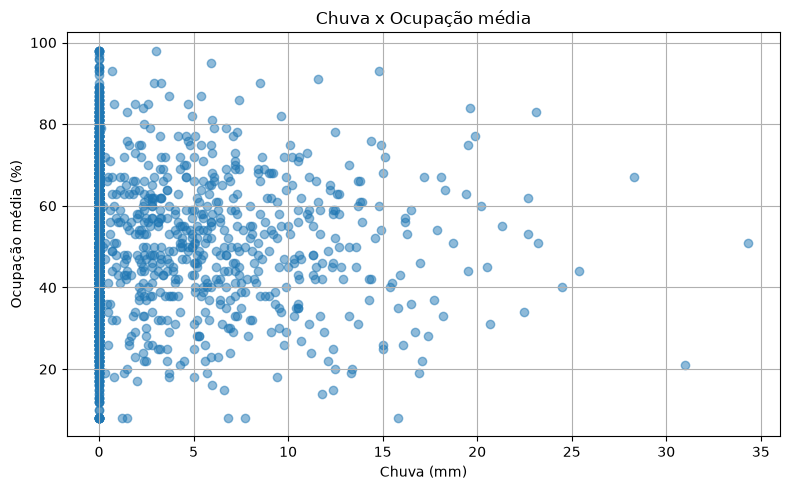


=== CORRELAÇÃO DE PEARSON - H4 ===
Correlação de Pearson: -0.0226
P-valor: 0.3129

=== CORRELAÇÃO DE SPEARMAN - H4 ===
Correlação de Spearman: -0.0146
P-valor: 0.5151

=== CONCLUSÃO - H4 ===
Resultado: não rejeitamos H0.
Não há evidências estatísticas suficientes para afirmar que maiores volumes de chuva estejam associados a maiores níveis de ocupação.


In [5]:
import os
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt

# Pasta de saida dos graficos (PNG para o relatorio)
PASTA_GRAFICOS = os.path.join("relatorio", "graficos")
os.makedirs(PASTA_GRAFICOS, exist_ok=True)


# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregando as bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

df_eventos = pd.read_excel(
    caminho,
    sheet_name="eventos_parada_cidade_alfa"
)

print("Bases carregadas com sucesso!")
print(f"Viagens: {df_viagens.shape}")
print(f"Eventos: {df_eventos.shape}")

print("\n=== H4 - CHUVA X OCUPAÇÃO ===")

print("\nEstatísticas da chuva:")
print(df_viagens["chuva_mm"].describe())

print("\nEstatísticas da ocupação:")
print(df_viagens["ocupacao_media_pct"].describe())

plt.figure(figsize=(8, 5))

plt.scatter(
    df_viagens["chuva_mm"],
    df_viagens["ocupacao_media_pct"],
    alpha=0.5
)

plt.title("Chuva x Ocupação média")
plt.xlabel("Chuva (mm)")
plt.ylabel("Ocupação média (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(PASTA_GRAFICOS, "H4_chuva_ocupacao.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# CORRELAÇÃO DE PEARSON
# ============================================================

print("\n=== CORRELAÇÃO DE PEARSON - H4 ===")

r_pearson, p_pearson = pearsonr(
    df_viagens["chuva_mm"],
    df_viagens["ocupacao_media_pct"]
)

print(f"Correlação de Pearson: {r_pearson:.4f}")

if p_pearson < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_pearson:.4f}")

# ============================================================
# CORRELAÇÃO DE SPEARMAN
# ============================================================

print("\n=== CORRELAÇÃO DE SPEARMAN - H4 ===")

rho, p_spearman = spearmanr(
    df_viagens["chuva_mm"],
    df_viagens["ocupacao_media_pct"]
)

print(f"Correlação de Spearman: {rho:.4f}")

if p_spearman < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_spearman:.4f}")

# ============================================================
# CONCLUSÃO
# ============================================================

print("\n=== CONCLUSÃO - H4 ===")

alpha = 0.05

if p_spearman < alpha and rho > 0:
    print("Resultado: rejeitamos H0.")
    print(
        "Há evidências de associação positiva estatisticamente "
        "significativa entre chuva e ocupação média."
    )
else:
    print("Resultado: não rejeitamos H0.")
    print(
        "Não há evidências estatísticas suficientes para afirmar "
        "que maiores volumes de chuva estejam associados a "
        "maiores níveis de ocupação."
    )


### Hipótese 5 — Ocupação x Consumo energético por km

Bases carregadas com sucesso!
Viagens: (2000, 28)
Eventos: (27413, 12)

=== H5 - OCUPAÇÃO X CONSUMO ENERGÉTICO POR KM ===

Estatísticas da ocupação média:
count    2000.000000
mean       51.091500
std        17.207591
min         8.000000
25%        39.000000
50%        51.000000
75%        63.000000
max        98.000000
Name: ocupacao_media_pct, dtype: float64

Estatísticas do consumo energético por km:
count    2000.000000
mean        1.486195
std         0.167767
min         0.950000
25%         1.380000
50%         1.480000
75%         1.600000
max         2.050000
Name: eficiencia_kwh_km, dtype: float64


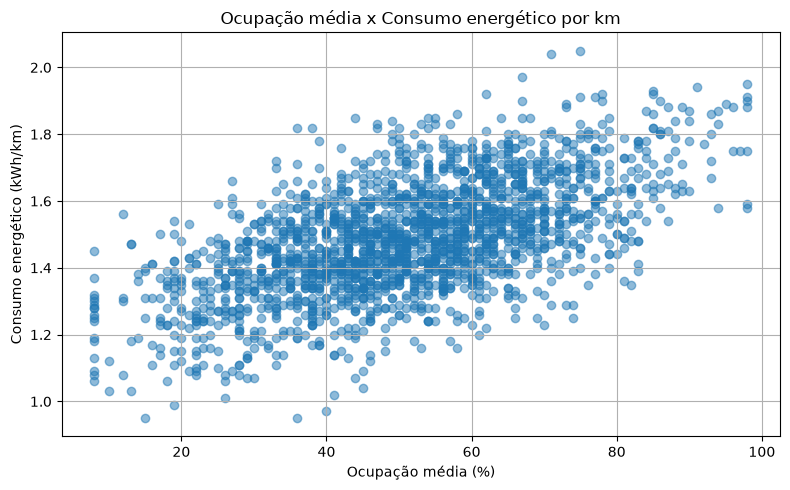


=== CORRELAÇÃO DE PEARSON - H5 ===
Correlação de Pearson: 0.5975
P-valor: < 0.001

=== CORRELAÇÃO DE SPEARMAN - H5 ===
Correlação de Spearman: 0.5745
P-valor: < 0.001

=== REGRESSÃO LINEAR - H5 ===
Intercepto: 1.1886
Coeficiente angular: 0.0058
R²: 0.3570
P-valor: < 0.001


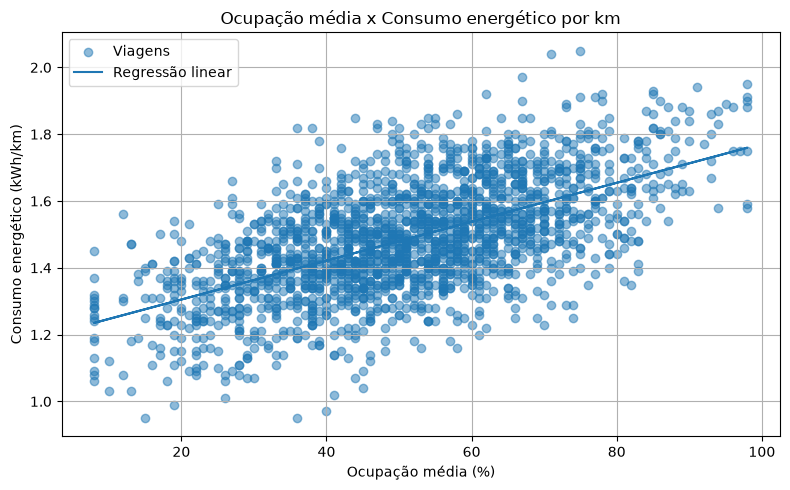


=== CONCLUSÃO - H5 ===
Resultado: rejeitamos H0.
Há evidências de associação positiva estatisticamente significativa entre a ocupação média e o consumo energético por km.

A regressão linear indica que a ocupação sozinha explica 35.7% da variação do consumo energético por km (R² = 0.3570).

Observação (limitação): a ocupação também é correlacionada com o congestionamento, que por sua vez também se associa ao consumo. Parte da relação observada pode, portanto, ser influenciada por esse terceiro fator.


'\nCONCLUSÃO - H5\n\nA correlação de Pearson entre ocupação média e consumo energético por km\nfoi de 0,5975 (p < 0.001) e a de Spearman, 0,5745 (p < 0.001): uma\nassociação positiva moderada e estatisticamente significativa. Quanto\nmais cheio o ônibus, maior o consumo de energia por quilômetro rodado.\n\nA regressão linear reforça o resultado: cada ponto percentual a mais de\nocupação está associado a cerca de 0,0058 kWh/km a mais de consumo, e a\nocupação sozinha explica aproximadamente 35,7% da variação do consumo\n(R² = 0,3570). Os outros ~64% vêm de fatores não considerados nesta\nhipótese.\n\nLIMITAÇÃO - possível confundimento:\nA ocupação média não é independente do congestionamento (r ≈ 0,45 nesta\nbase), e o congestionamento também está associado ao consumo energético.\nIsso significa que parte do efeito atribuído aqui à ocupação pode, na\nverdade, vir do trânsito enfrentado na viagem. A associação continua\nexistindo, mas seu tamanho deve ser lido com cautela: separar as dua

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

# Pasta de saida dos graficos (PNG para o relatorio)
PASTA_GRAFICOS = os.path.join("relatorio", "graficos")
os.makedirs(PASTA_GRAFICOS, exist_ok=True)


# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregando as bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

df_eventos = pd.read_excel(
    caminho,
    sheet_name="eventos_parada_cidade_alfa"
)

print("Bases carregadas com sucesso!")
print(f"Viagens: {df_viagens.shape}")
print(f"Eventos: {df_eventos.shape}")

# ============================================================
# H5 - OCUPAÇÃO X CONSUMO ENERGÉTICO POR KM
# ============================================================

print("\n=== H5 - OCUPAÇÃO X CONSUMO ENERGÉTICO POR KM ===")

print("\nEstatísticas da ocupação média:")
print(df_viagens["ocupacao_media_pct"].describe())

print("\nEstatísticas do consumo energético por km:")
print(df_viagens["eficiencia_kwh_km"].describe())

# ============================================================
# GRÁFICO DE DISPERSÃO
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df_viagens["ocupacao_media_pct"],
    df_viagens["eficiencia_kwh_km"],
    alpha=0.5
)

plt.title("Ocupação média x Consumo energético por km")
plt.xlabel("Ocupação média (%)")
plt.ylabel("Consumo energético (kWh/km)")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(PASTA_GRAFICOS, "H5_ocupacao_consumo.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# CORRELAÇÃO DE PEARSON
# ============================================================

print("\n=== CORRELAÇÃO DE PEARSON - H5 ===")

r_pearson, p_pearson = pearsonr(
    df_viagens["ocupacao_media_pct"],
    df_viagens["eficiencia_kwh_km"]
)

print(f"Correlação de Pearson: {r_pearson:.4f}")

if p_pearson < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_pearson:.4f}")

# ============================================================
# CORRELAÇÃO DE SPEARMAN
# ============================================================

print("\n=== CORRELAÇÃO DE SPEARMAN - H5 ===")

rho, p_spearman = spearmanr(
    df_viagens["ocupacao_media_pct"],
    df_viagens["eficiencia_kwh_km"]
)

print(f"Correlação de Spearman: {rho:.4f}")

if p_spearman < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_spearman:.4f}")

# ============================================================
# REGRESSÃO LINEAR - H5
# ============================================================

print("\n=== REGRESSÃO LINEAR - H5 ===")

x = df_viagens["ocupacao_media_pct"]
y = df_viagens["eficiencia_kwh_km"]

regressao = linregress(x, y)

print(f"Intercepto: {regressao.intercept:.4f}")
print(f"Coeficiente angular: {regressao.slope:.4f}")
print(f"R²: {regressao.rvalue**2:.4f}")

if regressao.pvalue < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {regressao.pvalue:.4f}")

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    alpha=0.5,
    label="Viagens"
)

plt.plot(
    x,
    regressao.intercept + regressao.slope * x,
    label="Regressão linear"
)

plt.title("Ocupação média x Consumo energético por km")
plt.xlabel("Ocupação média (%)")
plt.ylabel("Consumo energético (kWh/km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(PASTA_GRAFICOS, "H5_ocupacao_consumo_regressao.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# CONCLUSÃO - H5
# ============================================================

print("\n=== CONCLUSÃO - H5 ===")

alpha = 0.05

if p_pearson < alpha and r_pearson > 0:
    print("Resultado: rejeitamos H0.")
    print(
        "Há evidências de associação positiva estatisticamente "
        "significativa entre a ocupação média e o consumo "
        "energético por km."
    )
else:
    print("Resultado: não rejeitamos H0.")
    print(
        "Não há evidências estatísticas suficientes para afirmar "
        "que maior ocupação esteja associada a maior consumo "
        "energético por km."
    )

print(
    f"\nA regressão linear indica que a ocupação sozinha explica "
    f"{regressao.rvalue**2 * 100:.1f}% da variação do consumo "
    f"energético por km (R² = {regressao.rvalue**2:.4f})."
)

# ATENÇÃO - possível confundimento:
# A ocupação média também é correlacionada com o congestionamento
# (r ≈ 0,45 nesta base), e o congestionamento por si só também está
# associado ao consumo energético. Portanto, parte da relação medida
# aqui entre ocupação e consumo pode estar sendo influenciada por esse
# terceiro fator, e não apenas pelo peso dos passageiros. Isolar os dois
# efeitos exigiria regressão múltipla ou correlação parcial, o que está
# fora do escopo desta hipótese.

print(
    "\nObservação (limitação): a ocupação também é correlacionada com o "
    "congestionamento, que por sua vez também se associa ao consumo. "
    "Parte da relação observada pode, portanto, ser influenciada por "
    "esse terceiro fator."
)

"""
CONCLUSÃO - H5

A correlação de Pearson entre ocupação média e consumo energético por km
foi de 0,5975 (p < 0.001) e a de Spearman, 0,5745 (p < 0.001): uma
associação positiva moderada e estatisticamente significativa. Quanto
mais cheio o ônibus, maior o consumo de energia por quilômetro rodado.

A regressão linear reforça o resultado: cada ponto percentual a mais de
ocupação está associado a cerca de 0,0058 kWh/km a mais de consumo, e a
ocupação sozinha explica aproximadamente 35,7% da variação do consumo
(R² = 0,3570). Os outros ~64% vêm de fatores não considerados nesta
hipótese.

LIMITAÇÃO - possível confundimento:
A ocupação média não é independente do congestionamento (r ≈ 0,45 nesta
base), e o congestionamento também está associado ao consumo energético.
Isso significa que parte do efeito atribuído aqui à ocupação pode, na
verdade, vir do trânsito enfrentado na viagem. A associação continua
existindo, mas seu tamanho deve ser lido com cautela: separar as duas
contribuições exigiria uma regressão múltipla, que não foi aplicada
neste trabalho.
"""

### Hipótese 6 — Movimentação de passageiros x Tempo de parada

Bases carregadas com sucesso!
Viagens: (2000, 28)
Eventos: (27413, 12)

=== H6 - MOVIMENTAÇÃO DE PASSAGEIROS X TEMPO DE PARADA ===

Estatísticas da movimentação de passageiros:
count    27413.000000
mean        10.337796
std         11.999070
min          0.000000
25%          3.000000
50%          7.000000
75%         13.000000
max        181.000000
Name: movimentacao_passageiros, dtype: float64

Estatísticas do tempo de parada:
count    27413.000000
mean         1.344837
std          0.410055
min          0.350000
25%          1.070000
50%          1.340000
75%          1.610000
max          3.540000
Name: tempo_parada_min, dtype: float64


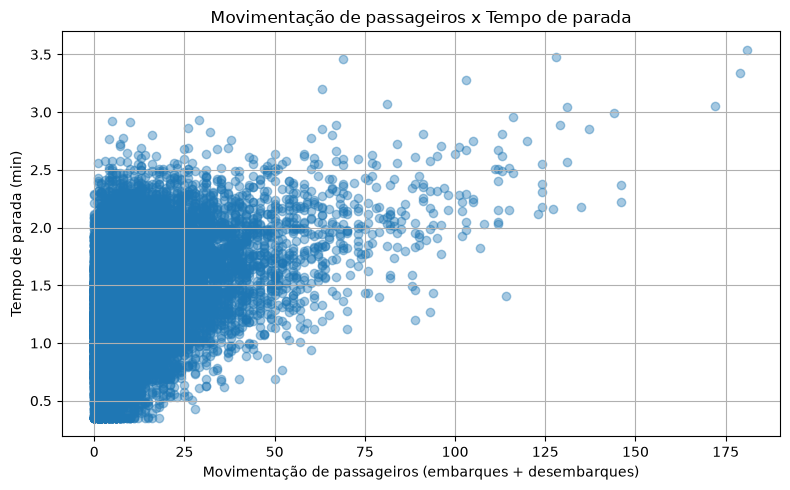


=== CORRELAÇÃO DE PEARSON - H6 ===
Correlação de Pearson: 0.3680
P-valor: < 0.001

=== CORRELAÇÃO DE SPEARMAN - H6 ===
Correlação de Spearman: 0.3276
P-valor: < 0.001

=== CONCLUSÃO - H6 ===
Resultado: rejeitamos H0.
Há evidências de associação positiva estatisticamente significativa entre a movimentação de passageiros e o tempo de parada.


In [7]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

# Pasta de saida dos graficos (PNG para o relatorio)
PASTA_GRAFICOS = os.path.join("relatorio", "graficos")
os.makedirs(PASTA_GRAFICOS, exist_ok=True)


# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregando as bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

df_eventos = pd.read_excel(
    caminho,
    sheet_name="eventos_parada_cidade_alfa"
)

print("Bases carregadas com sucesso!")
print(f"Viagens: {df_viagens.shape}")
print(f"Eventos: {df_eventos.shape}")

print("\n=== H6 - MOVIMENTAÇÃO DE PASSAGEIROS X TEMPO DE PARADA ===")

# Movimentação total de passageiros em cada parada
df_eventos["movimentacao_passageiros"] = (
    df_eventos["embarques"] +
    df_eventos["desembarques"]
)

# ============================================================
# ESTATÍSTICAS DESCRITIVAS
# ============================================================

print("\nEstatísticas da movimentação de passageiros:")
print(df_eventos["movimentacao_passageiros"].describe())

print("\nEstatísticas do tempo de parada:")
print(df_eventos["tempo_parada_min"].describe())

# ============================================================
# GRÁFICO DE DISPERSÃO
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df_eventos["movimentacao_passageiros"],
    df_eventos["tempo_parada_min"],
    alpha=0.4
)

plt.title("Movimentação de passageiros x Tempo de parada")
plt.xlabel("Movimentação de passageiros (embarques + desembarques)")
plt.ylabel("Tempo de parada (min)")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(PASTA_GRAFICOS, "H6_movimentacao_tempo_parada.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# CORRELAÇÃO DE PEARSON
# ============================================================

print("\n=== CORRELAÇÃO DE PEARSON - H6 ===")

r_pearson, p_pearson = pearsonr(
    df_eventos["movimentacao_passageiros"],
    df_eventos["tempo_parada_min"]
)

print(f"Correlação de Pearson: {r_pearson:.4f}")

if p_pearson < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_pearson:.4f}")

# ============================================================
# CORRELAÇÃO DE SPEARMAN
# ============================================================

print("\n=== CORRELAÇÃO DE SPEARMAN - H6 ===")

rho, p_spearman = spearmanr(
    df_eventos["movimentacao_passageiros"],
    df_eventos["tempo_parada_min"]
)

print(f"Correlação de Spearman: {rho:.4f}")

if p_spearman < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_spearman:.4f}")

# ============================================================
# CONCLUSÃO
# ============================================================

print("\n=== CONCLUSÃO - H6 ===")

alpha = 0.05

if p_spearman < alpha and rho > 0:
    print("Resultado: rejeitamos H0.")
    print(
        "Há evidências de associação positiva estatisticamente "
        "significativa entre a movimentação de passageiros "
        "e o tempo de parada."
    )
else:
    print("Resultado: não rejeitamos H0.")
    print(
        "Não há evidências estatísticas suficientes para afirmar "
        "que maior movimentação de passageiros esteja associada "
        "a maior tempo de parada."
    )


## 3. Visualização de dados e recomendações (Dashboard Streamlit)
> O código abaixo não roda diretamente como célula de notebook, pois depende do servidor Streamlit.
>
> Para rodar o dashboard, use um dos comandos abaixo, dependendo de onde está o terminal:
>
> - Da raiz do projeto: `streamlit run notebooks/fase_5/Dashboard.py`
> - De dentro de `notebooks/fase_5/`: `streamlit run Dashboard.py`
>
> O código do dashboard já não depende de onde ele é executado.

In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Configuração da página
st.set_page_config(
    page_title="Alpha Transit - Dashboard",
    page_icon="🚌",
    layout="wide"
)

# Identidade visual
st.markdown("""
<style>

.main-title {
    font-size: 2.5rem;
    font-weight: 800;
    color: #123B4A;
    margin-bottom: 0;
    letter-spacing: -1px;
}

.main-subtitle {
    font-size: 1.05rem;
    color: #5F737B;
    margin-top: 0;
}

.alpha-line {
    height: 5px;
    border-radius: 10px;
    background: linear-gradient(
        90deg,
        #123B4A 0%,
        #1F8A8A 55%,
        #F2B84B 100%
    );
    margin: 10px 0 25px 0;
}

.section-title {
    font-size: 1.25rem;
    font-weight: 700;
    color: #123B4A;
    margin-top: 30px;
    margin-bottom: 15px;
    padding-left: 10px;
    border-left: 4px solid #1F8A8A;
}

.kpi-card {
    background: white;
    border-radius: 12px;
    padding: 18px 20px;
    border: 1px solid #E1E8EB;
    border-top: 4px solid #1F8A8A;
    box-shadow: 0 2px 8px rgba(18, 59, 74, 0.08);
    min-height: 115px;
}

.kpi-title {
    font-size: 0.85rem;
    font-weight: 600;
    color: #5F737B;
    margin-bottom: 8px;
}

.kpi-value {
    font-size: 1.9rem;
    font-weight: 800;
    color: #123B4A;
}

.insight-card {
    background: white;
    border-radius: 12px;
    padding: 20px;
    border: 1px solid #E1E8EB;
    border-left: 4px solid #1F8A8A;
    box-shadow: 0 2px 8px rgba(18, 59, 74, 0.06);
    min-height: 190px;
}

.insight-title {
    font-size: 1.05rem;
    font-weight: 700;
    color: #123B4A;
    margin-bottom: 10px;
}

.insight-text {
    font-size: 0.92rem;
    line-height: 1.55;
    color: #52656D;
}

.recommendation-card {
    background: #F4F8F9;
    border-radius: 10px;
    padding: 15px 18px;
    margin-bottom: 10px;
    border-left: 4px solid #F2B84B;
    color: #40545C;
    line-height: 1.5;
}

.sidebar-title {
    font-size: 1.05rem;
    font-weight: 700;
    color: #123B4A;
    margin-bottom: 5px;
}

.sidebar-text {
    font-size: 0.85rem;
    color: #5F737B;
    margin-bottom: 15px;
}

</style>
""", unsafe_allow_html=True)

# Cabeçalho
st.markdown(
    '<div class="main-title">🚌 ALPHA TRANSIT</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="main-subtitle">'
    'Inteligência para a mobilidade urbana da Cidade Alpha'
    '</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="alpha-line"></div>',
    unsafe_allow_html=True
)

# Caminho da base de dados
caminho = "dados/Dados PBL fase 5.xlsx"

# Carregamento das bases
df_viagens = pd.read_excel(
    caminho,
    sheet_name="viagens_onibus_autonomos_cidade"
)

df_eventos = pd.read_excel(
    caminho,
    sheet_name="eventos_parada_cidade_alfa"
)

# Guarda a base original para análises que precisam considerar todos os períodos
df_viagens_base = df_viagens.copy()

# Filtro de período
periodos = ["Todos"] + sorted(
    df_viagens["periodo"].unique().tolist()
)

st.sidebar.markdown(
    '<div class="sidebar-title">🎛️ Filtros do painel</div>',
    unsafe_allow_html=True
)

st.sidebar.markdown(
    '<div class="sidebar-text">'
    'Selecione o período para explorar os indicadores.'
    '</div>',
    unsafe_allow_html=True
)

periodo_selecionado = st.sidebar.selectbox(
    "Período",
    periodos
)

# Aplica o filtro escolhido pelo usuário
if periodo_selecionado != "Todos":
    df_viagens = df_viagens[
        df_viagens["periodo"] == periodo_selecionado
    ]

    # Mantém nos eventos apenas as viagens do período selecionado
    ids_viagens = df_viagens["id_viagem"]

    df_eventos = df_eventos[
        df_eventos["id_viagem"].isin(ids_viagens)
    ]

# Indicadores principais
total_viagens = len(df_viagens)

atraso_medio = df_viagens["atraso_min"].mean()

congestionamento_medio = (
    df_viagens["congestionamento_pct"].mean()
)

ocupacao_media = (
    df_viagens["ocupacao_media_pct"].mean()
)

# Seção de indicadores
st.markdown(
    '<div class="section-title">📊 Indicadores principais</div>',
    unsafe_allow_html=True
)

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">🚌 Total de viagens</div>
            <div class="kpi-value">{total_viagens:,}</div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col2:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">⏱️ Atraso médio</div>
            <div class="kpi-value">{atraso_medio:.1f} min</div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col3:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">🚦 Congestionamento médio</div>
            <div class="kpi-value">{congestionamento_medio:.1f}%</div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col4:
    st.markdown(
        f"""
        <div class="kpi-card">
            <div class="kpi-title">👥 Ocupação média</div>
            <div class="kpi-value">{ocupacao_media:.1f}%</div>
        </div>
        """,
        unsafe_allow_html=True
    )

# Seção de análise
st.markdown(
    '<div class="section-title">📈 Relações entre os indicadores</div>',
    unsafe_allow_html=True
)

# Congestionamento x Atraso
col1, col2 = st.columns(2)

with col1:
    st.markdown("**Congestionamento x Atraso**")

    fig, ax = plt.subplots(figsize=(5, 3))

    ax.scatter(
        df_viagens["congestionamento_pct"],
        df_viagens["atraso_min"],
        alpha=0.35,
        s=18,
        color="#1F8A8A"
    )

    ax.set_xlabel("Congestionamento (%)")
    ax.set_ylabel("Atraso (minutos)")

    ax.grid(
        alpha=0.18,
        linestyle="--",
        linewidth=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#123B4A")
    ax.spines["bottom"].set_color("#123B4A")

    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

# Chuva x Congestionamento
with col2:
    st.markdown("**Chuva x Congestionamento**")

    fig, ax = plt.subplots(figsize=(5, 3))

    ax.scatter(
        df_viagens["chuva_mm"],
        df_viagens["congestionamento_pct"],
        alpha=0.35,
        s=18,
        color="#1F8A8A"
    )

    ax.set_xlabel("Chuva (mm)")
    ax.set_ylabel("Congestionamento (%)")

    ax.grid(
        alpha=0.18,
        linestyle="--",
        linewidth=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#123B4A")
    ax.spines["bottom"].set_color("#123B4A")

    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

# Chuva x Ocupação
col1, col2 = st.columns(2)

with col1:
    st.markdown("**Chuva x Ocupação**")

    fig, ax = plt.subplots(figsize=(5, 3))

    ax.scatter(
        df_viagens["chuva_mm"],
        df_viagens["ocupacao_media_pct"],
        alpha=0.35,
        s=18,
        color="#1F8A8A"
    )

    ax.set_xlabel("Chuva (mm)")
    ax.set_ylabel("Ocupação média (%)")

    ax.grid(
        alpha=0.18,
        linestyle="--",
        linewidth=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#123B4A")
    ax.spines["bottom"].set_color("#123B4A")

    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

# Ocupação x Consumo energético por km
with col2:
    st.markdown("**Ocupação x Consumo energético (kWh/km)**")

    fig, ax = plt.subplots(figsize=(5, 3))

    ax.scatter(
        df_viagens["ocupacao_media_pct"],
        df_viagens["eficiencia_kwh_km"],
        alpha=0.35,
        s=18,
        color="#1F8A8A"
    )

    ax.set_xlabel("Ocupação média (%)")
    ax.set_ylabel("Consumo energético (kWh/km)")

    ax.grid(
        alpha=0.18,
        linestyle="--",
        linewidth=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#123B4A")
    ax.spines["bottom"].set_color("#123B4A")

    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

# Calcula a movimentação total em cada parada
df_eventos["movimentacao_passageiros"] = (
    df_eventos["embarques"] +
    df_eventos["desembarques"]
)

# Seção de operação nas paradas
st.markdown(
    '<div class="section-title">🚌 Operação e movimentação nas paradas</div>',
    unsafe_allow_html=True
)

col1, col2, col3 = st.columns([1, 2, 1])

with col2:
    st.markdown("**Movimentação de passageiros x Tempo de parada**")

    fig, ax = plt.subplots(figsize=(5, 3))

    ax.scatter(
        df_eventos["movimentacao_passageiros"],
        df_eventos["tempo_parada_min"],
        alpha=0.3,
        s=12,
        color="#1F8A8A"
    )

    ax.set_xlabel("Movimentação de passageiros")
    ax.set_ylabel("Tempo de parada (min)")

    ax.grid(
        alpha=0.18,
        linestyle="--",
        linewidth=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#123B4A")
    ax.spines["bottom"].set_color("#123B4A")

    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

# Seção de desempenho por período
st.markdown(
    '<div class="section-title">🕐 Desempenho por período</div>',
    unsafe_allow_html=True
)

col1, col2, col3 = st.columns([1, 2, 1])

with col2:
    st.markdown("**Atraso médio por período**")

    atraso_periodo = (
        df_viagens_base.groupby("periodo")["atraso_min"]
        .mean()
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(5, 3))

    ax.bar(
        atraso_periodo.index,
        atraso_periodo.values,
        color="#F2B84B"
    )

    ax.set_xlabel("Período")
    ax.set_ylabel("Atraso médio (min)")

    ax.grid(
        axis="y",
        alpha=0.18,
        linestyle="--",
        linewidth=0.7
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("#123B4A")
    ax.spines["bottom"].set_color("#123B4A")

    plt.xticks(rotation=15)

    plt.tight_layout()
    st.pyplot(fig, use_container_width=True)
    plt.close(fig)

# Insights
st.divider()

st.markdown(
    '<div class="section-title">💡 Principais insights</div>',
    unsafe_allow_html=True
)

col1, col2, col3 = st.columns(3)

with col1:
    st.markdown(
        """
        <div class="insight-card">
            <div class="insight-title">🚦 Congestionamento</div>
            <div class="insight-text">
                Foi observada uma correlação positiva moderada entre
                congestionamento e atraso
                (Spearman &rho; = 0,55; p &lt; 0,001).
                Isso indica que maiores níveis de congestionamento
                tendem a estar associados a maiores atrasos.
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col2:
    st.markdown(
        """
        <div class="insight-card">
            <div class="insight-title">🕐 Horários de pico</div>
            <div class="insight-text">
                Os períodos de pico da manhã e da tarde apresentam
                os maiores atrasos médios, indicando maior impacto
                sobre o tempo das viagens.
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col3:
    st.markdown(
        """
        <div class="insight-card">
            <div class="insight-title">🚌 Movimentação nas paradas</div>
            <div class="insight-text">
                Maior movimentação de passageiros nas paradas
                tende a estar associada a maior tempo de parada.
            </div>
        </div>
        """,
        unsafe_allow_html=True
    )

# Recomendações
st.markdown(
    '<div class="section-title">🎯 Recomendações para a gestão pública</div>',
    unsafe_allow_html=True
)

st.markdown(
    """
    <div class="recommendation-card">
        <strong>Reforço operacional nos horários de pico</strong><br>
        Avaliar reforço operacional nos horários de pico,
        considerando os maiores atrasos observados nesses períodos.
    </div>

    <div class="recommendation-card">
        <strong>Monitoramento contínuo do congestionamento</strong><br>
        Monitorar continuamente os níveis de congestionamento da frota,
        já que ele está associado a mais atraso (H1), mas sem evidência
        até o momento de que alguma linha específica seja mais crítica
        que outra.
    </div>

    <div class="recommendation-card">
        <strong>Paradas com maior movimentação</strong><br>
        Identificar paradas com maior movimentação de passageiros,
        avaliando oportunidades para reduzir o tempo de embarque
        e desembarque.
    </div>
    """,
    unsafe_allow_html=True
)